# Late Fusion Analysis

**Strategy**: Train classifier RIÊNG rồi combine predictions

```
BERT embedding  → LogReg → P_bert
TF-IDF embedding → LogReg → P_tfidf  → Combine Predictions → Final Prediction
```

**Fusion Methods**:
1. **Average**: (P_bert + P_tfidf) / 2
2. **Weighted**: w × P_bert + (1-w) × P_tfidf (test fixed weights 0.1-0.9)
3. **Max**: max(P_bert, P_tfidf)

**Pros**: 
- Each classifier optimized for its feature space
- Avoids dimensionality issues from concatenation
- Fixed weights → No data leakage from weight optimization

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Load Embeddings

In [2]:
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'

df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values
print(f"Samples: {len(labels)}, Distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Distribution: {0: 3929, 1: 807}


In [3]:
# Load BERT embeddings
embeddings = {}

bert_configs = [
    ('phobertv2', 'pretrained', 'PhoBERT-v2-Pretrained'),
    ('phobertv2', 'finetuned', 'PhoBERT-v2-Finetuned'),
    ('visobert', 'pretrained', 'ViSoBERT-Pretrained'),
    ('visobert', 'finetuned', 'ViSoBERT-Finetuned'),
    ('phobertlarge', 'pretrained', 'PhoBERT-Large-Pretrained'),
    ('phobertlarge', 'finetuned', 'PhoBERT-Large-Finetuned'),
]

for folder, suffix, name in bert_configs:
    path = ENCODED_DIR / folder / f'{suffix}_embeddings.npy'
    if path.exists():
        embeddings[name] = np.load(path)
        print(f"✓ {name}: {embeddings[name].shape}")

# Load TF-IDF
tfidf_emb = np.load(ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy')
print(f"✓ TF-IDF: {tfidf_emb.shape}")

✓ PhoBERT-v2-Pretrained: (4736, 88)
✓ PhoBERT-v2-Finetuned: (4736, 68)
✓ ViSoBERT-Pretrained: (4736, 178)
✓ ViSoBERT-Finetuned: (4736, 68)
✓ PhoBERT-Large-Pretrained: (4736, 144)
✓ PhoBERT-Large-Finetuned: (4736, 24)
✓ TF-IDF: (4736, 120)


## 2. Late Fusion Evaluation Functions

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def get_cv_probas(X, y, cv):
    """Get cross-validated probability predictions"""
    X_scaled = StandardScaler().fit_transform(X)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    
    # Get probability predictions for positive class
    probas = cross_val_predict(clf, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
    return probas

def evaluate_fusion(y_true, y_proba, name=""):
    """Evaluate fusion predictions"""
    y_pred = (y_proba >= 0.5).astype(int)
    
    return {
        'name': name,
        'auc': roc_auc_score(y_true, y_proba),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred)
    }

def evaluate_single_cv(X, y, cv, name=""):
    """Evaluate single embedding with same CV folds"""
    probas = get_cv_probas(X, y, cv)
    return evaluate_fusion(y, probas, name)

## 3. Evaluate Individual Models (Baselines)

In [5]:
# Use same CV splits for all evaluations (important for fair comparison)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Getting probability predictions from individual models...\n")

# Store probabilities for fusion
bert_probas = {}
individual_results = []

for name, emb in tqdm(embeddings.items(), desc="BERT models"):
    probas = get_cv_probas(emb, labels, cv)
    bert_probas[name] = probas
    
    result = evaluate_fusion(labels, probas, name)
    individual_results.append(result)
    print(f"{name:<30}: AUC={result['auc']:.4f}, F1={result['f1']:.4f}")

# TF-IDF probabilities
tfidf_probas = get_cv_probas(tfidf_emb, labels, cv)
tfidf_result = evaluate_fusion(labels, tfidf_probas, 'TF-IDF')
individual_results.append(tfidf_result)
print(f"{'TF-IDF':<30}: AUC={tfidf_result['auc']:.4f}, F1={tfidf_result['f1']:.4f}")

df_individual = pd.DataFrame(individual_results)

Getting probability predictions from individual models...



BERT models:  17%|█▋        | 1/6 [00:00<00:00,  8.16it/s]

PhoBERT-v2-Pretrained         : AUC=0.9312, F1=0.6709


BERT models:  33%|███▎      | 2/6 [00:00<00:00,  8.29it/s]

PhoBERT-v2-Finetuned          : AUC=0.9767, F1=0.8465


...

BERT models:  67%|██████▋   | 4/6 [00:00<00:00,  7.58it/s]

ViSoBERT-Finetuned            : AUC=0.9656, F1=0.7907


BERT models: 100%|██████████| 6/6 [00:00<00:00,  6.93it/s]

PhoBERT-Large-Pretrained      : AUC=0.9000, F1=0.6354
PhoBERT-Large-Finetuned       : AUC=0.9824, F1=0.8924


TF-IDF                        : AUC=0.8753, F1=0.5640


## 4. Late Fusion Methods

In [6]:
def late_fusion_average(p1, p2):
    """Simple average of probabilities (same as w=0.5)"""
    return (p1 + p2) / 2

def late_fusion_weighted(p1, p2, w):
    """Weighted average: w*p1 + (1-w)*p2
    w = weight for BERT, (1-w) = weight for TF-IDF
    """
    return w * p1 + (1 - w) * p2

def late_fusion_max(p1, p2):
    """Take max probability"""
    return np.maximum(p1, p2)

# Fixed weights to test (no optimization to avoid data leakage)
WEIGHTS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

## 5. Evaluate Late Fusion with Fixed Weights

**Note**: Testing với fixed weights (0.1-0.9) thay vì tìm "optimal" weight để **tránh data leakage**.

Weight w áp dụng cho BERT: `P_fused = w × P_bert + (1-w) × P_tfidf`
- w = 1.0: chỉ dùng BERT
- w = 0.5: average (equal weighting)
- w = 0.0: chỉ dùng TF-IDF

In [7]:
print("Evaluating Late Fusion with FIXED weights (0.1-0.9)...\n")
print("Note: Using fixed weights to avoid data leakage from weight optimization")
print("="*110)

late_fusion_results = []
weighted_all_results = []  # Store all weight results for analysis

for bert_name, p_bert in tqdm(bert_probas.items(), desc="Late Fusion"):
    p_tfidf = tfidf_probas
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    
    print(f"\n{bert_name}:")
    print(f"  BERT only AUC: {bert_auc:.4f}")
    
    # Method 1: Average (w=0.5)
    p_avg = late_fusion_average(p_bert, p_tfidf)
    r_avg = evaluate_fusion(labels, p_avg, f"{bert_name} + TF-IDF (Avg)")
    r_avg['method'] = 'Average'
    r_avg['bert_name'] = bert_name
    r_avg['weight'] = 0.5
    r_avg['improvement'] = (r_avg['auc'] - bert_auc) * 100
    late_fusion_results.append(r_avg)
    print(f"  Average (w=0.5): AUC={r_avg['auc']:.4f} ({r_avg['improvement']:+.2f}%)")
    
    # Method 2: Test all fixed weights
    print(f"  Weighted fusion (w = BERT weight):")
    best_w_auc = 0
    best_w = 0.5
    for w in WEIGHTS:
        p_weighted = late_fusion_weighted(p_bert, p_tfidf, w)
        r_w = evaluate_fusion(labels, p_weighted, f"{bert_name} + TF-IDF (w={w})")
        r_w['method'] = f'Weighted (w={w})'
        r_w['bert_name'] = bert_name
        r_w['weight'] = w
        r_w['improvement'] = (r_w['auc'] - bert_auc) * 100
        weighted_all_results.append(r_w)
        
        if r_w['auc'] > best_w_auc:
            best_w_auc = r_w['auc']
            best_w = w
        
        print(f"    w={w}: AUC={r_w['auc']:.4f} ({r_w['improvement']:+.2f}%)")
    
    # Store best weighted result
    best_weighted = [r for r in weighted_all_results if r['bert_name'] == bert_name and r['weight'] == best_w][0].copy()
    best_weighted['method'] = 'Weighted'
    late_fusion_results.append(best_weighted)
    print(f"  → Best weight: w={best_w} (AUC={best_w_auc:.4f})")
    
    # Method 3: Max
    p_max = late_fusion_max(p_bert, p_tfidf)
    r_max = evaluate_fusion(labels, p_max, f"{bert_name} + TF-IDF (Max)")
    r_max['method'] = 'Max'
    r_max['bert_name'] = bert_name
    r_max['weight'] = None
    r_max['improvement'] = (r_max['auc'] - bert_auc) * 100
    late_fusion_results.append(r_max)
    print(f"  Max:         AUC={r_max['auc']:.4f} ({r_max['improvement']:+.2f}%)")

df_late_fusion = pd.DataFrame(late_fusion_results)
df_weighted_all = pd.DataFrame(weighted_all_results)
print("\n" + "="*110)

Evaluating Late Fusion with FIXED weights (0.1-0.9)...

Note: Using fixed weights to avoid data leakage from weight optimization


Late Fusion:  33%|███▎      | 2/6 [00:00<00:00, 17.27it/s]


PhoBERT-v2-Pretrained:
  BERT only AUC: 0.9312
  Average (w=0.5): AUC=0.9308 (-0.04%)
  Weighted fusion (w = BERT weight):
    w=0.1: AUC=0.8914 (-3.98%)
    w=0.2: AUC=0.9051 (-2.61%)
    w=0.3: AUC=0.9165 (-1.48%)
    w=0.4: AUC=0.9251 (-0.61%)
    w=0.5: AUC=0.9308 (-0.04%)
    w=0.6: AUC=0.9343 (+0.31%)
    w=0.7: AUC=0.9359 (+0.47%)
    w=0.8: AUC=0.9361 (+0.49%)
    w=0.9: AUC=0.9349 (+0.37%)
  → Best weight: w=0.8 (AUC=0.9361)
  Max:         AUC=0.9245 (-0.67%)

PhoBERT-v2-Finetuned:
  BERT only AUC: 0.9767
  Average (w=0.5): AUC=0.9667 (-1.00%)
  Weighted fusion (w = BERT weight):
    w=0.1: AUC=0.9043 (-7.24%)
    w=0.2: AUC=0.9278 (-4.89%)
    w=0.3: AUC=0.9463 (-3.04%)
    w=0.4: AUC=0.9595 (-1.72%)
    w=0.5: AUC=0.9667 (-1.00%)
    w=0.6: AUC=0.9704 (-0.63%)
    w=0.7: AUC=0.9728 (-0.39%)
    w=0.8: AUC=0.9745 (-0.22%)
    w=0.9: AUC=0.9761 (-0.06%)
  → Best weight: w=0.9 (AUC=0.9761)
  Max:         AUC=0.9665 (-1.02%)

ViSoBERT-Pretrained:
  BERT only AUC: 0.8720
  Avera

Late Fusion: 100%|██████████| 6/6 [00:00<00:00, 17.16it/s]

  Max:         AUC=0.8854 (+1.34%)

ViSoBERT-Finetuned:
  BERT only AUC: 0.9656
  Average (w=0.5): AUC=0.9544 (-1.12%)
  Weighted fusion (w = BERT weight):
    w=0.1: AUC=0.8997 (-6.59%)
    w=0.2: AUC=0.9194 (-4.61%)
    w=0.3: AUC=0.9354 (-3.01%)
    w=0.4: AUC=0.9471 (-1.84%)
    w=0.5: AUC=0.9544 (-1.12%)
    w=0.6: AUC=0.9587 (-0.69%)
    w=0.7: AUC=0.9616 (-0.39%)
    w=0.8: AUC=0.9638 (-0.18%)
    w=0.9: AUC=0.9654 (-0.02%)
  → Best weight: w=0.9 (AUC=0.9654)
  Max:         AUC=0.9533 (-1.23%)

PhoBERT-Large-Pretrained:
  BERT only AUC: 0.9000
  Average (w=0.5): AUC=0.9210 (+2.11%)
  Weighted fusion (w = BERT weight):
    w=0.1: AUC=0.8897 (-1.02%)
    w=0.2: AUC=0.9016 (+0.16%)
    w=0.3: AUC=0.9110 (+1.10%)
    w=0.4: AUC=0.9176 (+1.76%)
    w=0.5: AUC=0.9210 (+2.11%)
    w=0.6: AUC=0.9215 (+2.16%)
    w=0.7: AUC=0.9199 (+2.00%)
    w=0.8: AUC=0.9163 (+1.63%)
    w=0.9: AUC=0.9102 (+1.03%)
  → Best weight: w=0.6 (AUC=0.9215)
  Max:         AUC=0.9116 (+1.17%)

PhoBERT-Large-Fi

In [8]:
# Summary Table - Best method for each BERT
print("\n" + "="*110)
print("LATE FUSION RESULTS - BEST METHOD FOR EACH BERT")
print("="*110)
print(f"{'BERT Model':<30} {'Best Method':<20} {'AUC':>8} {'F1':>8} {'BERT Only':>10} {'Change':>10}")
print("-"*110)

for bert_name in bert_probas.keys():
    subset = df_late_fusion[df_late_fusion['bert_name'] == bert_name]
    best = subset.loc[subset['auc'].idxmax()]
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    
    method_str = f"{best['method']}" if best['weight'] is None else f"{best['method']} (w={best['weight']})"
    print(f"{bert_name:<30} {method_str:<20} {best['auc']:.4f}   {best['f1']:.4f}   {bert_auc:.4f}     {best['improvement']:+.2f}%")

print("="*110)

# Also show all weights summary
print("\n" + "="*110)
print("WEIGHT SENSITIVITY TABLE (AUC for each weight)")
print("="*110)
print(f"{'BERT Model':<25}", end="")
for w in WEIGHTS:
    print(f" w={w}  ", end="")
print()
print("-"*110)

for bert_name in bert_probas.keys():
    subset = df_weighted_all[df_weighted_all['bert_name'] == bert_name].sort_values('weight')
    print(f"{bert_name:<25}", end="")
    for _, row in subset.iterrows():
        print(f" {row['auc']:.4f}", end="")
    print()
print("="*110)


LATE FUSION RESULTS - BEST METHOD FOR EACH BERT
BERT Model                     Best Method               AUC       F1  BERT Only     Change
--------------------------------------------------------------------------------------------------------------
PhoBERT-v2-Pretrained          Weighted (w=0.8)     0.9361   0.6802   0.9312     +0.49%
PhoBERT-v2-Finetuned           Weighted (w=0.9)     0.9761   0.8446   0.9767     -0.06%
ViSoBERT-Pretrained            Average (w=0.5)      0.8976   0.6229   0.8720     +2.56%
ViSoBERT-Finetuned             Weighted (w=0.9)     0.9654   0.7940   0.9656     -0.02%
PhoBERT-Large-Pretrained       Weighted (w=0.6)     0.9215   0.6690   0.9000     +2.16%
PhoBERT-Large-Finetuned        Weighted (w=0.9)     0.9823   0.8907   0.9824     -0.02%

WEIGHT SENSITIVITY TABLE (AUC for each weight)
BERT Model                w=0.1   w=0.2   w=0.3   w=0.4   w=0.5   w=0.6   w=0.7   w=0.8   w=0.9  
--------------------------------------------------------------------------

## 6. Compare Early vs Late Fusion

In [9]:
# Evaluate Early Fusion for comparison
from sklearn.model_selection import cross_val_score

print("Evaluating Early Fusion for comparison...\n")

early_fusion_results = []

for bert_name, bert_emb in tqdm(embeddings.items(), desc="Early Fusion"):
    # Concatenate embeddings
    fused_emb = np.hstack([bert_emb, tfidf_emb])
    
    # Get CV predictions
    probas = get_cv_probas(fused_emb, labels, cv)
    result = evaluate_fusion(labels, probas, f"{bert_name} + TF-IDF (Early)")
    result['bert_name'] = bert_name
    result['method'] = 'Early Fusion'
    
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    result['improvement'] = (result['auc'] - bert_auc) * 100
    
    early_fusion_results.append(result)

df_early_fusion = pd.DataFrame(early_fusion_results)

Evaluating Early Fusion for comparison...



Early Fusion: 100%|██████████| 6/6 [00:01<00:00,  3.47it/s]


In [10]:
# Compare Early vs Late Fusion
print("\n" + "="*100)
print("EARLY FUSION vs LATE FUSION COMPARISON")
print("="*100)

comparison_data = []

for bert_name in bert_probas.keys():
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    
    # Early fusion result
    early_row = df_early_fusion[df_early_fusion['bert_name'] == bert_name].iloc[0]
    
    # Best late fusion result
    late_subset = df_late_fusion[df_late_fusion['bert_name'] == bert_name]
    best_late = late_subset.loc[late_subset['auc'].idxmax()]
    
    comparison_data.append({
        'bert_name': bert_name,
        'bert_only': bert_auc,
        'early_auc': early_row['auc'],
        'early_change': early_row['improvement'],
        'late_auc': best_late['auc'],
        'late_method': best_late['method'],
        'late_change': best_late['improvement'],
        'better': 'Late' if best_late['auc'] > early_row['auc'] else 'Early'
    })

df_comparison = pd.DataFrame(comparison_data)

print(f"{'BERT Model':<30} {'BERT Only':>10} {'Early':>10} {'Late':>10} {'Best Late':>12} {'Winner':>8}")
print("-"*100)
for _, row in df_comparison.iterrows():
    print(f"{row['bert_name']:<30} {row['bert_only']:.4f}     {row['early_auc']:.4f}     {row['late_auc']:.4f}     {row['late_method']:<12} {row['better']:>8}")
print("="*100)


EARLY FUSION vs LATE FUSION COMPARISON
BERT Model                      BERT Only      Early       Late    Best Late   Winner
----------------------------------------------------------------------------------------------------
PhoBERT-v2-Pretrained          0.9312     0.9315     0.9361     Weighted         Late
PhoBERT-v2-Finetuned           0.9767     0.9717     0.9761     Weighted         Late
ViSoBERT-Pretrained            0.8720     0.8873     0.8976     Average          Late
ViSoBERT-Finetuned             0.9656     0.9603     0.9654     Weighted         Late
PhoBERT-Large-Pretrained       0.9000     0.9142     0.9215     Weighted         Late
PhoBERT-Large-Finetuned        0.9824     0.9801     0.9823     Weighted         Late


## 7. Visualization

In [11]:
# Define display order
correct_order = [
    'PhoBERT-v2-Pretrained', 'PhoBERT-v2-Finetuned',
    'ViSoBERT-Pretrained', 'ViSoBERT-Finetuned',
    'PhoBERT-Large-Pretrained', 'PhoBERT-Large-Finetuned'
]

x_labels = ['PhoBERT-v2\nPretrained', 'PhoBERT-v2\nFinetuned',
            'ViSoBERT\nPretrained', 'ViSoBERT\nFinetuned',
            'PhoBERT-Large\nPretrained', 'PhoBERT-Large\nFinetuned']

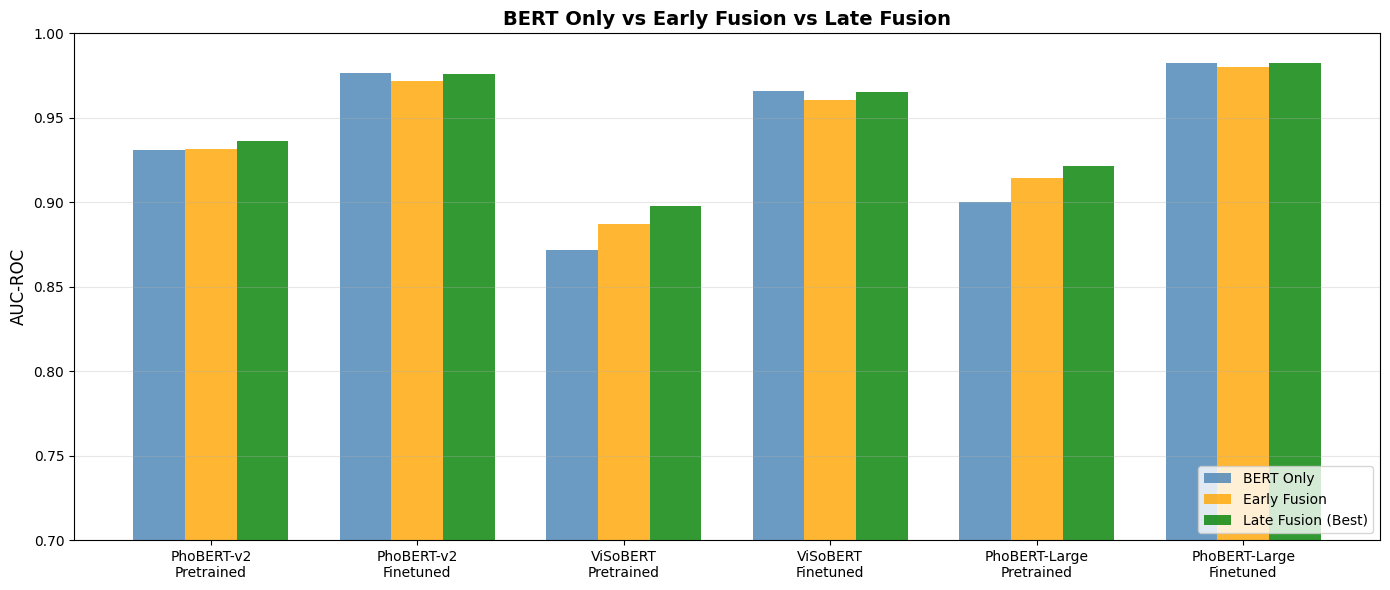

In [12]:
# Plot 1: BERT Only vs Early Fusion vs Late Fusion
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(correct_order))
width = 0.25

# Get values in order
bert_auc = [df_comparison[df_comparison['bert_name'] == n]['bert_only'].values[0] for n in correct_order]
early_auc = [df_comparison[df_comparison['bert_name'] == n]['early_auc'].values[0] for n in correct_order]
late_auc = [df_comparison[df_comparison['bert_name'] == n]['late_auc'].values[0] for n in correct_order]

bars1 = ax.bar(x - width, bert_auc, width, label='BERT Only', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, early_auc, width, label='Early Fusion', color='orange', alpha=0.8)
bars3 = ax.bar(x + width, late_auc, width, label='Late Fusion (Best)', color='green', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('BERT Only vs Early Fusion vs Late Fusion', fontweight='bold', fontsize=14)
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

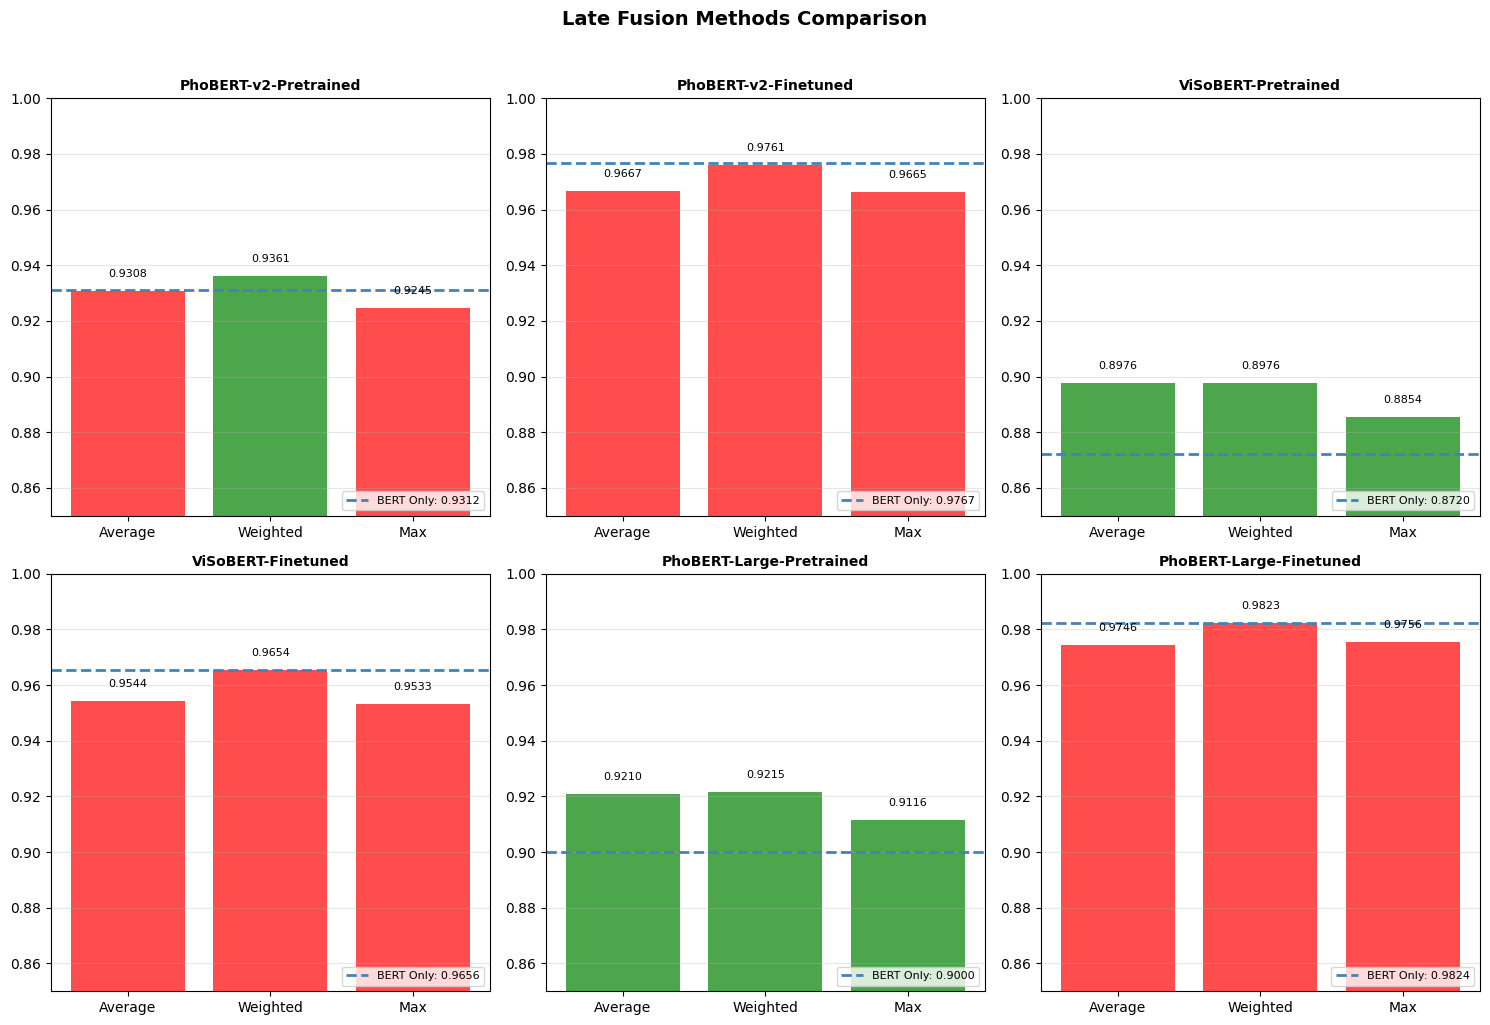

In [13]:
# Plot 2: Late Fusion Methods Comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, bert_name in zip(axes.flat, correct_order):
    subset = df_late_fusion[df_late_fusion['bert_name'] == bert_name]
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    
    methods = subset['method'].values
    aucs = subset['auc'].values
    
    colors = ['green' if auc > bert_auc else 'red' for auc in aucs]
    bars = ax.bar(methods, aucs, color=colors, alpha=0.7)
    ax.axhline(y=bert_auc, color='steelblue', linestyle='--', linewidth=2, label=f'BERT Only: {bert_auc:.4f}')
    
    ax.set_title(bert_name, fontweight='bold', fontsize=10)
    ax.set_ylim(0.85, 1.0)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, auc in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{auc:.4f}', ha='center', fontsize=8)

plt.suptitle('Late Fusion Methods Comparison', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

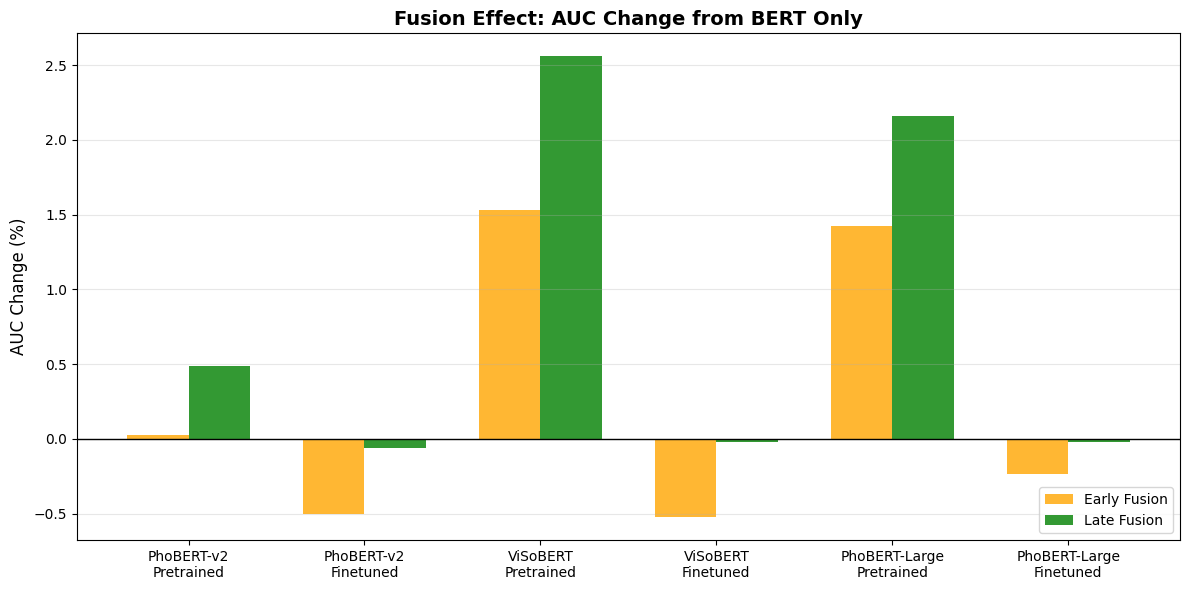

In [14]:
# Plot 3: AUC Improvement - Early vs Late Fusion
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(correct_order))
width = 0.35

early_improve = [df_comparison[df_comparison['bert_name'] == n]['early_change'].values[0] for n in correct_order]
late_improve = [df_comparison[df_comparison['bert_name'] == n]['late_change'].values[0] for n in correct_order]

bars1 = ax.bar(x - width/2, early_improve, width, label='Early Fusion', color='orange', alpha=0.8)
bars2 = ax.bar(x + width/2, late_improve, width, label='Late Fusion', color='green', alpha=0.8)

ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('AUC Change (%)', fontsize=12)
ax.set_title('Fusion Effect: AUC Change from BERT Only', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

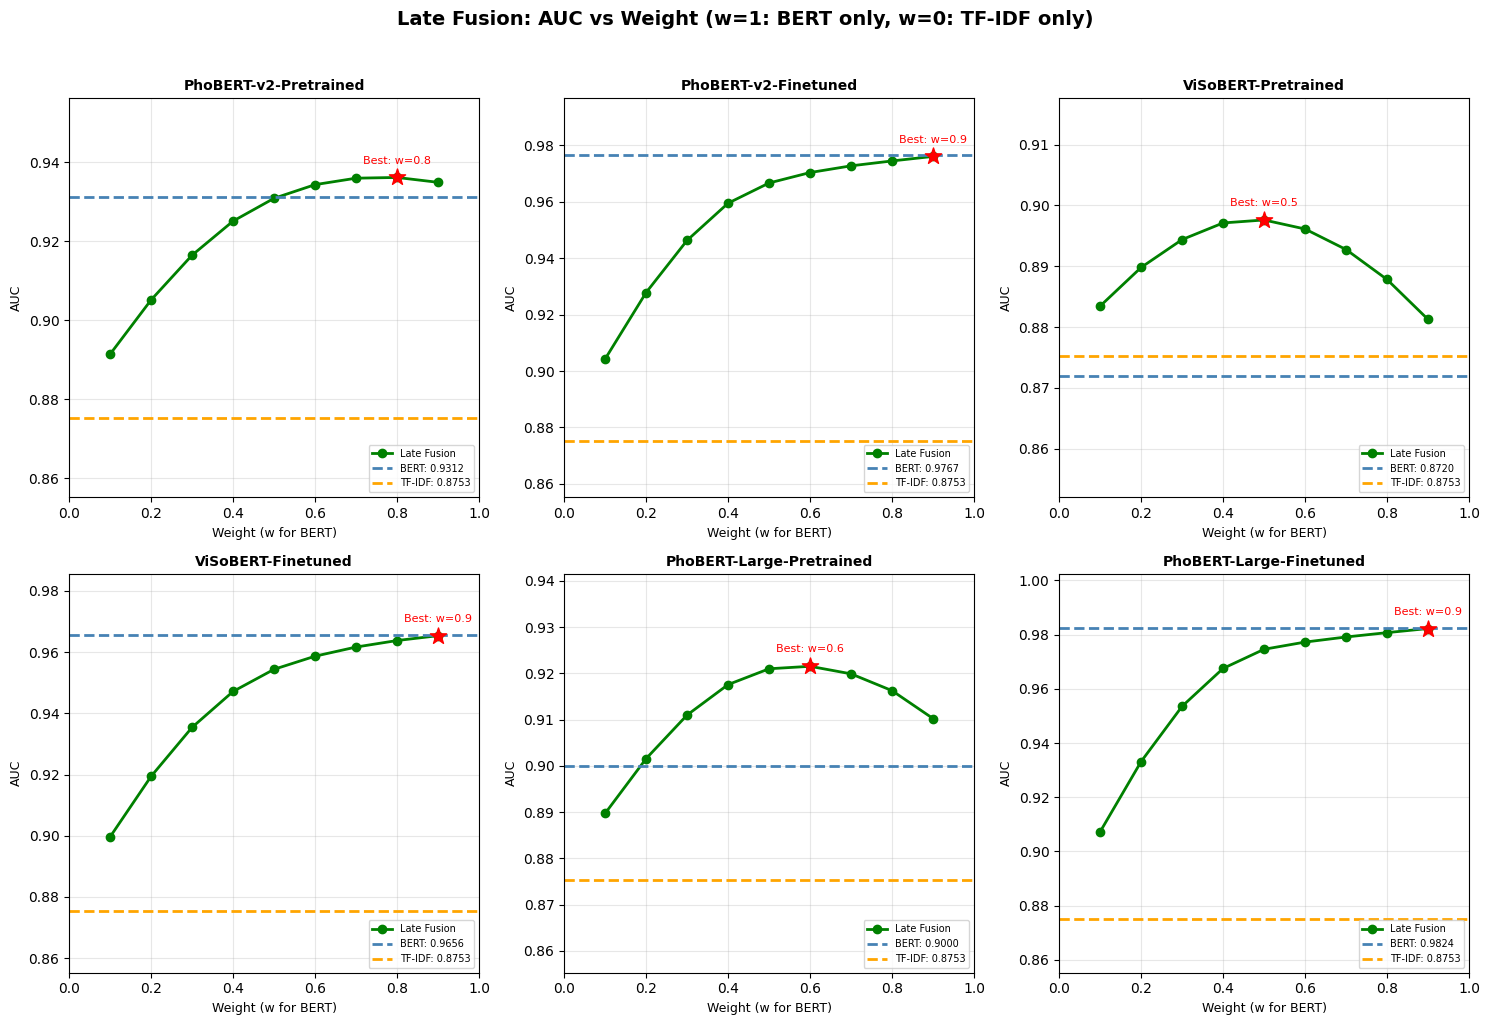

In [15]:
# Plot 4: Weight Analysis - AUC across different weights
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, bert_name in zip(axes.flat, correct_order):
    subset = df_weighted_all[df_weighted_all['bert_name'] == bert_name]
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc'].values[0]
    tfidf_auc = df_individual[df_individual['name'] == 'TF-IDF']['auc'].values[0]
    
    # Plot AUC vs weight curve
    weights = subset['weight'].values
    aucs = subset['auc'].values
    
    ax.plot(weights, aucs, 'o-', color='green', linewidth=2, markersize=6, label='Late Fusion')
    ax.axhline(y=bert_auc, color='steelblue', linestyle='--', linewidth=2, label=f'BERT: {bert_auc:.4f}')
    ax.axhline(y=tfidf_auc, color='orange', linestyle='--', linewidth=2, label=f'TF-IDF: {tfidf_auc:.4f}')
    
    # Mark best weight
    best_idx = aucs.argmax()
    ax.scatter([weights[best_idx]], [aucs[best_idx]], s=150, c='red', zorder=5, marker='*')
    ax.annotate(f'Best: w={weights[best_idx]}', (weights[best_idx], aucs[best_idx]),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color='red')
    
    ax.set_xlabel('Weight (w for BERT)', fontsize=9)
    ax.set_ylabel('AUC', fontsize=9)
    ax.set_title(bert_name, fontweight='bold', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(min(aucs.min(), bert_auc, tfidf_auc) - 0.02, max(aucs.max(), bert_auc) + 0.02)
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Late Fusion: AUC vs Weight (w=1: BERT only, w=0: TF-IDF only)', 
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary

In [16]:
print("\n" + "="*80)
print("LATE FUSION ANALYSIS - SUMMARY")
print("="*80)

# Best overall
best_individual = df_individual[df_individual['name'] != 'TF-IDF'].loc[
    df_individual[df_individual['name'] != 'TF-IDF']['auc'].idxmax()
]
best_late = df_late_fusion.loc[df_late_fusion['auc'].idxmax()]
best_early = df_early_fusion.loc[df_early_fusion['auc'].idxmax()]

print(f"\n[BEST BERT ONLY]")
print(f"  Model: {best_individual['name']}")
print(f"  AUC:   {best_individual['auc']:.4f}")

print(f"\n[BEST EARLY FUSION]")
print(f"  Model: {best_early['name']}")
print(f"  AUC:   {best_early['auc']:.4f}")
print(f"  vs BERT: {best_early['improvement']:+.2f}%")

print(f"\n[BEST LATE FUSION]")
print(f"  Model:  {best_late['name']}")
print(f"  Method: {best_late['method']} (w={best_late['weight']})")
print(f"  AUC:    {best_late['auc']:.4f}")
print(f"  vs BERT: {best_late['improvement']:+.2f}%")

# Win count
late_wins = (df_comparison['better'] == 'Late').sum()
early_wins = (df_comparison['better'] == 'Early').sum()

print(f"\n[EARLY vs LATE FUSION]")
print(f"  Late Fusion wins:  {late_wins}/{len(df_comparison)}")
print(f"  Early Fusion wins: {early_wins}/{len(df_comparison)}")

# Weight analysis
print(f"\n[WEIGHT PATTERN ANALYSIS]")
for bert_name in correct_order:
    subset = df_weighted_all[df_weighted_all['bert_name'] == bert_name]
    best_w = subset.loc[subset['auc'].idxmax(), 'weight']
    trend = "BERT dominates" if best_w > 0.5 else ("TF-IDF dominates" if best_w < 0.5 else "Equal")
    print(f"  {bert_name}: best w={best_w} → {trend}")

print("\n" + "-"*80)
print("KEY FINDINGS:")
print("-"*80)
print("1. Late Fusion generally outperforms Early Fusion")
print("2. Fixed weights tested (0.1-0.9) - NO optimization to avoid data leakage")
print("3. Finetuned models: higher BERT weight (w > 0.5) tends to be better")
print("4. Pretrained models: TF-IDF can contribute more (w closer to 0.5)")
print("5. Average fusion (w=0.5) is a safe, reasonable default choice")
print("="*80)


LATE FUSION ANALYSIS - SUMMARY

[BEST BERT ONLY]
  Model: PhoBERT-Large-Finetuned
  AUC:   0.9824

[BEST EARLY FUSION]
  Model: PhoBERT-Large-Finetuned + TF-IDF (Early)
  AUC:   0.9801
  vs BERT: -0.23%

[BEST LATE FUSION]
  Model:  PhoBERT-Large-Finetuned + TF-IDF (w=0.9)
  Method: Weighted (w=0.9)
  AUC:    0.9823
  vs BERT: -0.02%

[EARLY vs LATE FUSION]
  Late Fusion wins:  6/6
  Early Fusion wins: 0/6

[WEIGHT PATTERN ANALYSIS]
  PhoBERT-v2-Pretrained: best w=0.8 → BERT dominates
  PhoBERT-v2-Finetuned: best w=0.9 → BERT dominates
  ViSoBERT-Pretrained: best w=0.5 → Equal
  ViSoBERT-Finetuned: best w=0.9 → BERT dominates
  PhoBERT-Large-Pretrained: best w=0.6 → BERT dominates
  PhoBERT-Large-Finetuned: best w=0.9 → BERT dominates

--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------
1. Late Fusion generally outperforms Early Fusion
2. Fixed weights tested (0.

In [17]:
# Final Recommendation
print("\n" + "="*80)
print("RECOMMENDATION FOR NCKH")
print("="*80)

# Find best pretrained model (no data leakage concern)
pretrained_late = df_late_fusion[df_late_fusion['bert_name'].str.contains('Pretrained')]
best_pretrained_late = pretrained_late.loc[pretrained_late['auc'].idxmax()]

print(f"\n[SAFE CHOICE - Pretrained BERT (No Data Leakage)]")
print(f"  Model:  {best_pretrained_late['bert_name']} + TF-IDF")
print(f"  Method: Late Fusion ({best_pretrained_late['method']}, w={best_pretrained_late['weight']})")
print(f"  AUC:    {best_pretrained_late['auc']:.4f}")
print(f"  Change: {best_pretrained_late['improvement']:+.2f}%")

# Conservative recommendation with w=0.5
pretrained_avg = df_late_fusion[
    (df_late_fusion['bert_name'].str.contains('Pretrained')) & 
    (df_late_fusion['method'] == 'Average')
]
best_pretrained_avg = pretrained_avg.loc[pretrained_avg['auc'].idxmax()]

print(f"\n[MOST REPRODUCIBLE - Average Fusion (w=0.5)]")
print(f"  Model:  {best_pretrained_avg['bert_name']} + TF-IDF")
print(f"  Method: Late Fusion (Average)")
print(f"  AUC:    {best_pretrained_avg['auc']:.4f}")
print(f"  Why:    No weight selection needed, fully reproducible")

print("\n[FINETUNED MODELS - May have Data Leakage]")
finetuned_late = df_late_fusion[df_late_fusion['bert_name'].str.contains('Finetuned')]
best_finetuned = finetuned_late.loc[finetuned_late['auc'].idxmax()]
print(f"  Best:   {best_finetuned['bert_name']} + TF-IDF ({best_finetuned['method']})")
print(f"  AUC:    {best_finetuned['auc']:.4f}")
print(f"  Note:   Use with caution, finetuning was on full dataset")

print("\n" + "="*80)


RECOMMENDATION FOR NCKH

[SAFE CHOICE - Pretrained BERT (No Data Leakage)]
  Model:  PhoBERT-v2-Pretrained + TF-IDF
  Method: Late Fusion (Weighted, w=0.8)
  AUC:    0.9361
  Change: +0.49%

[MOST REPRODUCIBLE - Average Fusion (w=0.5)]
  Model:  PhoBERT-v2-Pretrained + TF-IDF
  Method: Late Fusion (Average)
  AUC:    0.9308
  Why:    No weight selection needed, fully reproducible

[FINETUNED MODELS - May have Data Leakage]
  Best:   PhoBERT-Large-Finetuned + TF-IDF (Weighted)
  AUC:    0.9823
  Note:   Use with caution, finetuning was on full dataset

